In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [20]:
df=pd.read_csv('train (1).csv')

In [21]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [22]:

df.shape

(9800, 18)

In [23]:
sales_df=df[['Order Date','Sales']]

In [24]:
sales_df.head()

,Order Date,Sales
0,08/11/2017,261.9600
1,08/11/2017,731.9400
2,12/06/2017,14.6200
3,11/10/2016,957.5775
4,11/10/2016,22.3680


In [29]:
from datetime import datetime

In [33]:
sales_df=pd.DataFrame(sales_df)
sales_df['Order Date'] =pd.to_datetime(sales_df['Order Date'],format='%d/%m/%Y')

In [34]:
sales_df.head()

,Order Date,Sales
0,2017-11-08,261.9600
1,2017-11-08,731.9400
2,2017-06-12,14.6200
3,2016-10-11,957.5775
4,2016-10-11,22.3680


In [36]:
df1=sales_df.set_index('Order Date')

In [37]:
df1.head()

,Sales
Order Date,
2017-11-08,261.9600
2017-11-08,731.9400
2017-06-12,14.6200
2016-10-11,957.5775
2016-10-11,22.3680


In [38]:
monthly_sales=df1.resample('M').mean()

C:\Users\91637\AppData\Local\Temp\ipykernel_23272\939251271.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales=df1.resample('M').mean()


In [42]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,184.489701
2015-02-28,98.258522
2015-03-31,358.479201
2015-04-30,214.668115
2015-05-31,195.407463


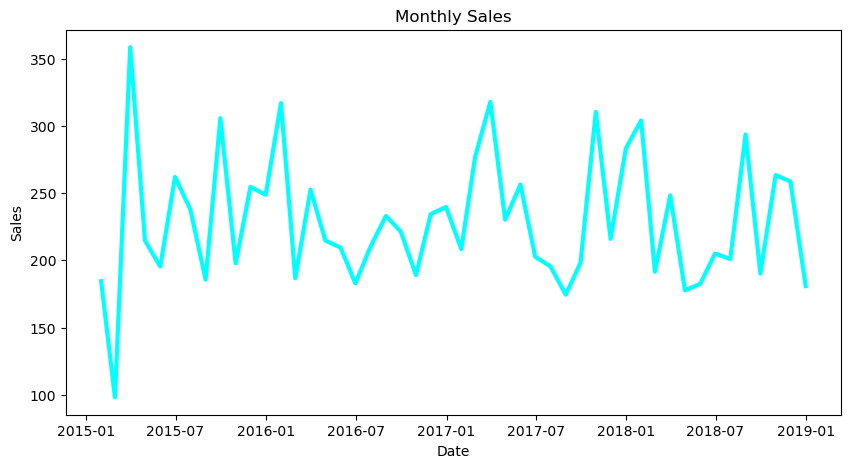

In [52]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales,label='Monthly Sales',linewidth=3,c='cyan')
plt.title('Monthly Sales')

plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

In [54]:
result=adfuller(monthly_sales,autolag='AIC')# The autolag parameter lets the ADF function automatically select the 
                                                 # optimal number of lags based on an information criterion.
print('ADF Stats:',result[0])
print('p-value:',result[1])
if result[1]<0.05:
    print('Stationary')
else: print('Non Stationary')

ADF Stats: -3.2577227100967785
p-value: 0.01687732973623261
Stationary


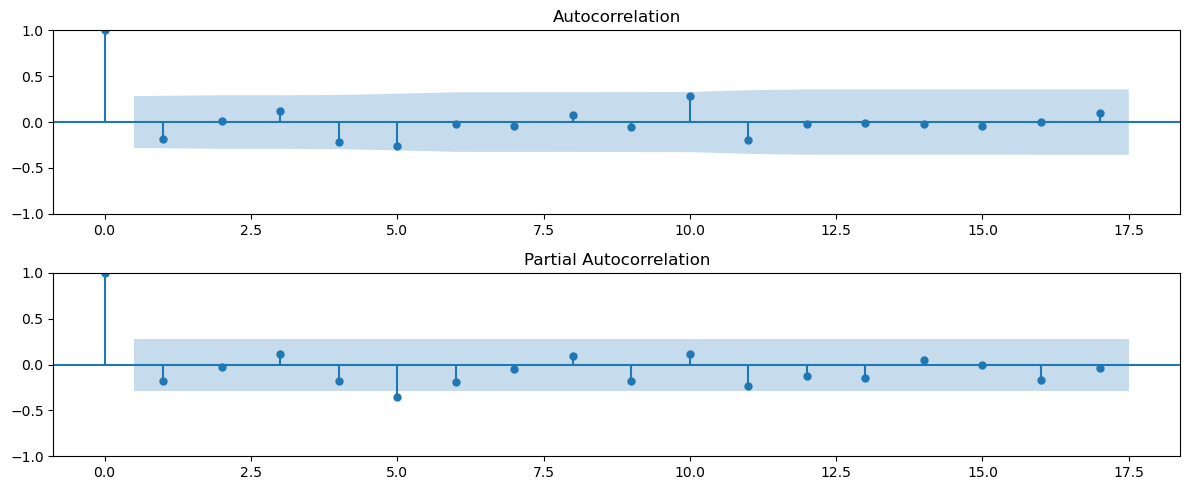

In [56]:
fig,ax=plt.subplots(2,1,figsize=(12,5))
plot_acf(monthly_sales,ax=ax[0])
plot_pacf(monthly_sales,ax=ax[1])

plt.tight_layout()

In [57]:
model=SARIMAX(monthly_sales,order=(1,1,1),seasonal_order=(1,1,1,12))
mdl_fit=model.fit()


  warn('Too few observations to estimate starting parameters%s.'


In [58]:
model

In [59]:
mdl_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.256
Date:                            Sat, 21 Jun 2025   AIC                            398.513
Time:                                    15:01:04   BIC                            406.289
Sample:                                01-31-2015   HQIC                           401.197
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1276      0.297     -0.430      0.667      -0.709       0.454
ma.L1         -0.9991     25.417     -0.039      0.969     -50.815      48.817
ar.S.L12      -0.5908      0.518     -1.142      0.254      -1.605       0.423
ma.S.L12      -0.0325      0.781     -0.042      0.967      -1.563       1.498
sigma2      2915.9550   7.39e+04      0.039      0.969   -1.42e+05    1.48e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.58
Prob(Q):                              0.95   Prob(JB):                         0.10
Heteroskedasticity (H):               0.67   Skew:                             0.62
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

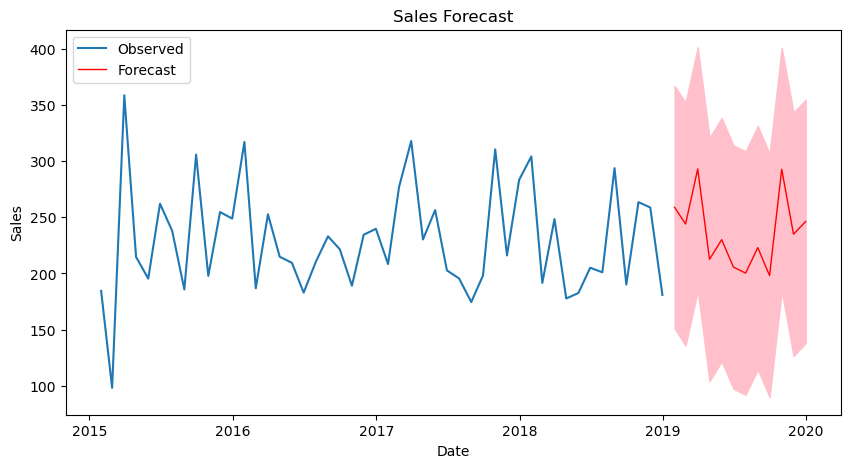

In [63]:
frcst_period=12
forecast=mdl_fit.get_forecast(steps=12)
frcst_mean=forecast.predicted_mean
frcst_ci=forecast.conf_int()   # forecast.conf_int() returns the confidence interval of the forecasted values.gives you a range of uncertainty.

plt.figure(figsize=(10,5))
plt.plot(monthly_sales,label='Observed')
plt.plot(frcst_mean,label='Forecast',linewidth=1,c='red')
plt.fill_between(frcst_ci.index,frcst_ci.iloc[:,0],frcst_ci.iloc[:,1],color='pink') # is used to plot the confidence interval (shaded area) 
                                                                                    # around your forecast in a time series plot using Matplotlib.

plt.title('Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.show()

In [66]:
observed=monthly_sales[-frcst_period:]
mae=mean_absolute_error(observed,frcst_mean)
mse=mean_squared_error(observed,frcst_mean)
print('MAE:',mae)
print('MSE',mse)

MAE: 35.218878357227275
MSE 1748.637803792128
